In [ ]:
from abc import ABC, abstractmethod
from dataclasses import dataclass
from collections import deque
from typing import Any, Dict, Iterable, List, Optional, Tuple
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches

In [ ]:
class Problem(ABC):
    """Abstract base class for a search problem."""

    @abstractmethod
    def initial_state(self) -> Any:
        """Return the start state."""
        pass

    @abstractmethod
    def is_goal(self, state: Any) -> bool:
        """Return True if state is a goal state."""
        pass

    @abstractmethod
    def actions(self, state: Any) -> List[Any]:
        """Return the legal actions available in the given state."""
        pass

    @abstractmethod
    def result(self, state: Any, action: Any) -> Any:
        """Return the next state after applying action in state."""
        pass

    @abstractmethod
    def action_cost(self, state: Any, action: Any, next_state: Any) -> float:
        """Return the cost of applying action in state to reach next_state."""
        pass

In [ ]:
@dataclass
class Node:
    state: Any
    parent: Optional["Node"] = None
    action: Optional[Any] = None
    path_cost: float = 0
    depth: int = 0

    def __post_init__(self):
        if self.parent is not None:
            self.depth = self.parent.depth + 1


@dataclass
class SearchResult:
    algorithm: str
    status: str
    solution: Optional[Node]
    nodes_expanded: int
    max_frontier_size: int
    reached_count: int = 0
    limit: Optional[int] = None
    iterations: Optional[List[Dict[str, Any]]] = None

    @property
    def path(self) -> Optional[List[Any]]:
        if self.solution is None:
            return None
        return reconstruct_path(self.solution)

    @property
    def solution_depth(self) -> Optional[int]:
        if self.solution is None:
            return None
        return self.solution.depth

    @property
    def solution_cost(self) -> Optional[float]:
        if self.solution is None:
            return None
        return self.solution.path_cost
    
    

In [ ]:
def reconstruct_path(node: Node) -> List[Any]:
    """Return the list of states from the root node to this node."""
    path = []

    while node is not None:
        path.append(node.state)
        node = node.parent

    path.reverse()
    return path


def reconstruct_actions(node: Node) -> List[Any]:
    """Return the list of actions from the root node to this node."""
    actions = []

    while node is not None and node.parent is not None:
        actions.append(node.action)
        node = node.parent

    actions.reverse()
    return actions


def state_is_on_path(node: Node, state: Any) -> bool:
    """
    Return True if state already appears on the path from the root to node.

    This is useful for depth-limited search because DLS often uses path-cycle
    checking instead of a global reached set.
    """
    while node is not None:
        if node.state == state:
            return True
        node = node.parent

    return False


def result_to_row(result: SearchResult) -> Dict[str, Any]:
    """Convert a SearchResult object into a row for a pandas DataFrame."""
    return {
        "Algorithm": result.algorithm,
        "Status": result.status,
        "Limit": result.limit,
        "Solution depth": result.solution_depth,
        "Solution cost": result.solution_cost,
        "Nodes expanded": result.nodes_expanded,
        "Max frontier/stack": result.max_frontier_size,
        "Reached states": result.reached_count,
    }


def show_results(results: List[SearchResult]) -> pd.DataFrame:
    """Display results as a DataFrame."""
    return pd.DataFrame([result_to_row(r) for r in results])

In [ ]:
MOVES = {
    "UP": (-1, 0),
    "DOWN": (1, 0),
    "LEFT": (0, -1),
    "RIGHT": (0, 1),
}


class GridProblem(Problem):
    def __init__(
        self,
        grid: List[List[int]],
        start: Tuple[int, int],
        goal: Tuple[int, int],
    ):
        """
        grid:
            2D list where 0 = free cell and 1 = obstacle.

        start, goal:
            Tuples in the form (row, col).
        """
        self.grid = grid
        self.start = start
        self.goal = goal

        self.rows = len(grid)
        self.cols = len(grid[0])

    def initial_state(self) -> Tuple[int, int]:
        return self.start

    def is_goal(self, state: Tuple[int, int]) -> bool:
        # TODO 1:
        # Return True if state is equal to the goal state.
        return state == self.goal
        # raise NotImplementedError("Complete GridProblem.is_goal")

    def in_bounds(self, state: Tuple[int, int]) -> bool:
        row, col = state
        return 0 <= row < self.rows and 0 <= col < self.cols

    def is_free(self, state: Tuple[int, int]) -> bool:
        row, col = state
        return self.grid[row][col] == 0

    def actions(self, state: Tuple[int, int]) -> List[str]:
        # TODO 2:
        # Return a list of legal action names.
        #
        # Steps:
        # 1. Create an empty list called legal_actions.
        # 2. For each action in MOVES:
        #       a. Compute the neighbour cell.
        #       b. Check that it is in bounds.
        #       c. Check that it is free.
        #       d. If valid, add the action name to legal_actions.
        # 3. Return legal_actions.
        legal_actions = []

        for action, move_coordinate in MOVES.items():
            row, col = state
            change_in_row, change_in_col = move_coordinate
            neighbour = (row + change_in_row, col + change_in_col)

            if self.in_bounds(neighbour) and self.is_free(neighbour):
                legal_actions.append(action)

        return legal_actions
        # raise NotImplementedError("Complete GridProblem.actions")

    def result(self, state: Tuple[int, int], action: str) -> Tuple[int, int]:
        # TODO 3:
        # Return the next state after applying action to state.
        #
        # Hint:
        # dr, dc = MOVES[action]
        # return (row + dr, col + dc)
        row, col = state
        change_in_row, change_in_col = MOVES[action]
        return (row + change_in_row, col + change_in_col)
        # raise NotImplementedError("Complete GridProblem.result")

    def action_cost(
        self,
        state: Tuple[int, int],
        action: str,
        next_state: Tuple[int, int],
    ) -> float:
        # TODO 4:
        # In this lab, each valid move has a cost of 1.
        # Return 1.
        return 1.0
        # raise NotImplementedError("Complete GridProblem.action_cost")

In [ ]:
test_grid = [
    [0, 0, 0],
    [1, 1, 0],
    [0, 0, 0],
]

test_problem = GridProblem(test_grid, start=(0, 0), goal=(2, 2))

assert test_problem.initial_state() == (0, 0)
assert test_problem.is_goal((2, 2)) is True
assert test_problem.is_goal((0, 0)) is False
assert test_problem.actions((0, 0)) == ["RIGHT"]
assert test_problem.result((0, 0), "RIGHT") == (0, 1)
assert test_problem.action_cost((0, 0), "RIGHT", (0, 1)) == 1

print("GridProblem self-check passed.")

GridProblem self-check passed.


In [ ]:
sample_grid = [
    [0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
    [1, 1, 1, 0, 1, 0, 1, 1, 1, 0],
    [0, 0, 0, 0, 0, 0, 1, 0, 0, 0],
    [0, 1, 1, 1, 1, 0, 1, 0, 1, 1],
    [0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
    [0, 1, 1, 0, 1, 1, 1, 1, 1, 0],
    [0, 0, 1, 0, 0, 0, 0, 0, 1, 0],
    [1, 0, 1, 1, 1, 1, 1, 0, 1, 0],
    [0, 0, 0, 0, 0, 0, 1, 0, 0, 0],
    [0, 1, 1, 1, 1, 0, 0, 0, 1, 0],
]

start = (0, 0)
goal = (9, 9)

problem = GridProblem(sample_grid, start, goal)

In [ ]:
def plot_path(
    grid: List[List[int]],
    start: Optional[Tuple[int, int]] = None,
    goal: Optional[Tuple[int, int]] = None,
    path: Optional[List[Tuple[int, int]]] = None,
    terrain_costs: Optional[List[List[float]]] = None,
    title: str = "Grid Map",
):
    """Visualise a grid and, optionally, a solution path."""
    arr = np.array(grid)
    height, width = arr.shape

    path_set = set(path) if path is not None else set()

    fig, ax = plt.subplots(figsize=(7, 7))
    ax.set_xlim(0, width)
    ax.set_ylim(height, 0)
    ax.set_aspect("equal")
    ax.axis("off")
    ax.set_title(title)

    for row in range(height):
        for col in range(width):
            state = (row, col)

            if arr[row, col] == 1:
                fill = (0.15, 0.15, 0.15)
            elif start is not None and state == start:
                fill = (0.95, 0.20, 0.20)
            elif goal is not None and state == goal:
                fill = (0.20, 0.70, 0.25)
            elif state in path_set:
                fill = (0.95, 0.90, 0.35)
            else:
                fill = (0.95, 0.95, 0.95)

            rect = patches.Rectangle(
                (col, row),
                1,
                1,
                linewidth=1,
                edgecolor=(0.75, 0.75, 0.75),
                facecolor=fill,
            )
            ax.add_patch(rect)

            if terrain_costs is not None and arr[row, col] == 0:
                ax.text(
                    col + 0.5,
                    row + 0.5,
                    str(terrain_costs[row][col]),
                    ha="center",
                    va="center",
                    fontsize=8,
                )

    plt.show()

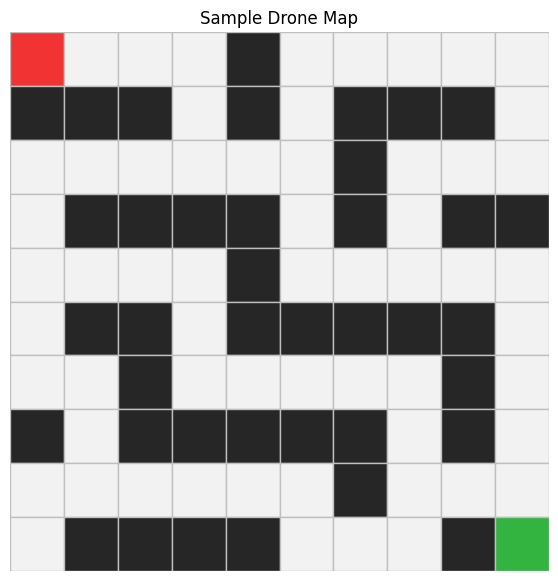

In [ ]:
plot_path(sample_grid, start, goal, title="Sample Drone Map")

In [ ]:
class SearchAlgorithm(ABC):
    """Base class for search algorithms."""

    def expand(self, problem: Problem, node: Node) -> Iterable[Node]:
        # TODO 5:
        # Implement the AIMA-style EXPAND(problem, node).
        #
        # Pseudocode:
        # s <- node.STATE
        # for each action in problem.ACTIONS(s):
        #     s_prime <- problem.RESULT(s, action)
        #     cost <- node.PATH_COST + problem.ACTION_COST(s, action, s_prime)
        #     yield NODE(STATE=s_prime, PARENT=node, ACTION=action, PATH_COST=cost)
        state = node.state
        
        for action in problem.actions(state):
          state_prime = problem.result(state, action)
          cost = node.path_cost + problem.action_cost(state, action, state_prime)
          
          yield Node(state_prime, node, action, cost)
          

    @abstractmethod
    def search(self, problem: Problem) -> SearchResult:
        pass

In [ ]:
class BreadthFirstSearch(SearchAlgorithm):
    def search(self, problem: Problem) -> SearchResult:
        algorithm = "BFS"

        # TODO 6:
        # Implement BFS graph search using a FIFO queue.
        #
        # Steps:
        # 1. Create the initial node from problem.initial_state().
        initial_node = Node(problem.initial_state())
        
        # Initialize tracking metrics required for the final SearchResult
        nodes_expanded = 0
        max_frontier_size = 1
        
        # 2. If the initial state is the goal, return success.
        if problem.is_goal(initial_node.state):
          return SearchResult(algorithm, "SUCCESS", initial_node, nodes_expanded, max_frontier_size)
        
        # 3. Create a deque frontier and add the initial node.
        frontier = deque([initial_node])
        
        # 4. Create a reached set and add the initial state.
        reached = {initial_node.state}
        
        # 5. While frontier is not empty:
        #       a. pop from the LEFT of the deque.
        #       b. increment nodes_expanded.
        #       c. expand the node.
        while frontier:
          node = frontier.popleft()
          nodes_expanded += 1
          
        # d. for each child:
          for child in self.expand(problem, node):
            if problem.is_goal(child.state):
        #     i. if child is goal, return success.
              return SearchResult(algorithm, "SUCCESS", child, nodes_expanded, max_frontier_size)
        #     ii. if child.state is not in reached:
            if child.state not in reached:
          #   add child.state to reached.
              reached.add(child.state)
          #   append child to frontier.
              frontier.append(child)
            
        # e. update max_frontier_size.
          max_frontier_size = max(max_frontier_size, len(frontier))   
                 
        # 6. Return failure if no solution is found.
        return SearchResult(algorithm, "FAILURE", None, nodes_expanded, max_frontier_size)
        #
        # Hint:
        # frontier = deque([node])
        # node = frontier.popleft()
       
        # raise NotImplementedError("Complete BreadthFirstSearch.search")

In [ ]:
class DepthFirstSearch(SearchAlgorithm):
    def search(self, problem: Problem) -> SearchResult:
        algorithm = "DFS"

        # TODO 7:
        # Implement DFS graph search using a stack.
        #
        # Steps:
        # 1. Create the initial node.
        initial_node = Node(problem.initial_state())
        
        # Initialize tracking metrics required for the final SearchResult
        nodes_expanded = 0
        max_frontier_size = 1
        
        # 2. If the initial state is the goal, return success.
        if problem.is_goal(initial_node.state):
            return SearchResult(algorithm, "SUCCESS", initial_node, nodes_expanded, max_frontier_size)
               
        # 3. Use a Python list as the stack frontier.
        frontier = [initial_node]
        
        # 4. Use a reached set.
        reached = {initial_node.state}
        
        # 5. While frontier is not empty:
        while frontier:
        #       a. pop from the end of the list.
            node = frontier.pop()
        #       b. increment nodes_expanded.
            nodes_expanded += 1
        #       c. expand the node.
            for child in self.expand(problem, node):
                if problem.is_goal(child.state):
                    return SearchResult(algorithm, "SUCCESS", child, nodes_expanded, max_frontier_size)
                
        #       d. add unreached children to the stack.
                if child.state not in reached:
                    reached.add(child.state)
                    frontier.append(child)
                
        #   e. update max_frontier_size.
            max_frontier_size = max(max_frontier_size, len(frontier))
        
        return SearchResult(algorithm, "FAILURE", None, nodes_expanded, max_frontier_size)
        #
        # Note:
        # If you want DFS to explore actions in the same order as MOVES,
        # you may need to reverse the children before pushing them.
        # raise NotImplementedError("Complete DepthFirstSearch.search")

In [ ]:
class DepthLimitedSearch(SearchAlgorithm):
    def search(self, problem: Problem, limit: int = 10) -> SearchResult:
        algorithm = "DLS"

        initial_node = Node(problem.initial_state())

        metrics = {
            "nodes_expanded": 0,
            "max_stack_size": 1,
        }

        solution, status = self._recursive_dls(
            problem=problem,
            node=initial_node,
            limit=limit,
            metrics=metrics,
            current_stack_size=1,
        )

        return SearchResult(
            algorithm=algorithm,
            status=status,
            solution=solution,
            nodes_expanded=metrics["nodes_expanded"],
            max_frontier_size=metrics["max_stack_size"],
            reached_count=0,
            limit=limit,
        )

    def _recursive_dls(
        self,
        problem: Problem,
        node: Node,
        limit: int,
        metrics: Dict[str, int],
        current_stack_size: int,
    ) -> Tuple[Optional[Node], str]:
        # TODO 8:
        # Implement recursive depth-limited search.
        #
        # Steps:
        # 1. If node.state is goal, return (node, "success").
        if problem.is_goal(node.state):
            return (node, "SUCCESS")
        # 2. Else if node.depth >= limit, return (None, "cutoff").
        elif node.depth >= limit:
            return (None, "CUTOFF")
        # 3. Otherwise:
        else:
        #   a. increment metrics["nodes_expanded"].
            metrics["nodes_expanded"] += 1

        #   b. set cutoff_occurred = False.
            cutoff_occurred = False

        #   c. for each child in expand(problem, node):
            for child in self.expand(problem, node):
        #       i. skip the child if child.state already appears on the current path.
                if state_is_on_path(node, child.state):
                    continue
        #       ii. update max_stack_size.
                metrics["max_stack_size"] = max(metrics["max_stack_size"], current_stack_size + 1)
                    
        #       iii. recursively call _recursive_dls on the child.
                result_node, result_status = self._recursive_dls(problem=problem, node=child, limit=limit, metrics=metrics, current_stack_size=current_stack_size + 1)
                
        #       iv. if result is "success", return success immediately.
                if result_status ==  "SUCCESS":
                    return (result_node, "SUCCESS")
                
        #       v. if result is "cutoff", set cutoff_occurred = True.
                if result_status == "CUTOFF":
                    cutoff_occurred = True
        
        #   d. after all children:
        #      if cutoff_occurred, return (None, "cutoff")
            if cutoff_occurred:
                return (None, "CUTOFF")

        #   else return (None, "failure")
            return (None, "FAILURE")
        # raise NotImplementedError("Complete DepthLimitedSearch._recursive_dls")

In [ ]:
class IterativeDeepeningSearch(SearchAlgorithm):
    def search(self, problem: Problem, max_depth: int = 50) -> SearchResult:
        algorithm = "IDS"

        # TODO 9:
        # Implement IDS by repeatedly running DLS from limit 0 to max_depth.
        #
        # Requirements:
        # 1. Keep a list called iteration_log.
        iteration_log = []

        # Initialize tracking metrics required for the final SearchResult
        nodes_expanded = 0
        max_stack_size = 0

        # 2. Accumulate total nodes expanded across all DLS iterations.
        for limit in range(max_depth + 1):
            dls = DepthLimitedSearch()
            result = dls.search(problem, limit=limit)

            nodes_expanded += result.nodes_expanded

            # 3. Track the maximum stack size seen in any DLS run.
            max_stack_size = max(
                max_stack_size,
                result.max_frontier_size
            )

            iteration_log.append({
                "limit": limit,
                "status": result.status,
                "solution_depth": result.solution_depth,
                "solution_cost": result.solution_cost,
                "nodes_expanded": result.nodes_expanded,
                "max_stack_size": result.max_frontier_size,
            })

            # 4. If a DLS run returns success, return a SearchResult for IDS.
            if result.status == "SUCCESS":
                return SearchResult(algorithm=algorithm, status="SUCCESS", solution=result.solution, nodes_expanded=nodes_expanded, max_frontier_size=max_stack_size, reached_count=0, limit=limit, iterations=iteration_log,
                )

            # 5. If a DLS run returns failure, IDS can stop early and return failure.
            if result.status == "FAILURE":
                return SearchResult(algorithm=algorithm, status="FAILURE", solution=None, nodes_expanded=nodes_expanded, max_frontier_size=max_stack_size, reached_count=0, limit=limit, iterations=iteration_log,
                )

        # 6. If all limits return cutoff up to max_depth, return cutoff.
        return SearchResult(algorithm=algorithm, status="CUTOFF", solution=None, nodes_expanded=nodes_expanded, max_frontier_size=max_stack_size, reached_count=0, limit=max_depth, iterations=iteration_log,
        )

        #
        # Hint:
        # dls = DepthLimitedSearch()
        # result = dls.search(problem, limit=limit)

In [ ]:
bfs = BreadthFirstSearch()
dfs = DepthFirstSearch()
dls = DepthLimitedSearch()
ids = IterativeDeepeningSearch()

results = [
    bfs.search(problem),
    dfs.search(problem),
    dls.search(problem, limit=10),
    ids.search(problem, max_depth=30),
]

show_results(results)

,Algorithm,Status,Limit,Solution depth,Solution cost,Nodes expanded,Max frontier/stack,Reached states
0,BFS,SUCCESS,NaN,18.0,18.0,50,5,0
1,DFS,SUCCESS,NaN,18.0,18.0,18,4,0
2,DLS,CUTOFF,10.0,NaN,NaN,16,11,0
3,IDS,SUCCESS,18.0,18.0,18.0,356,19,0


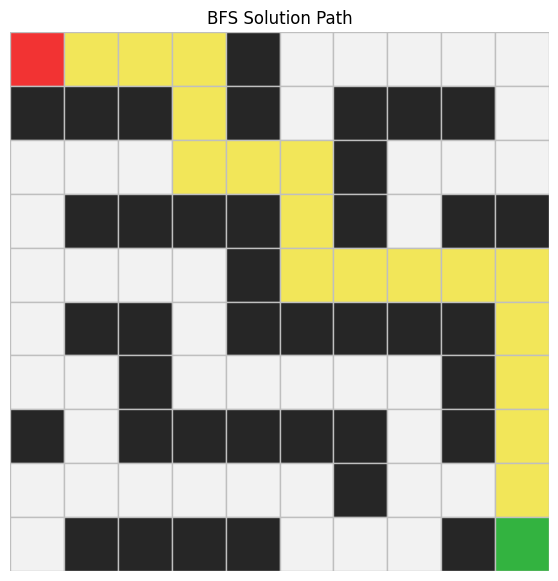

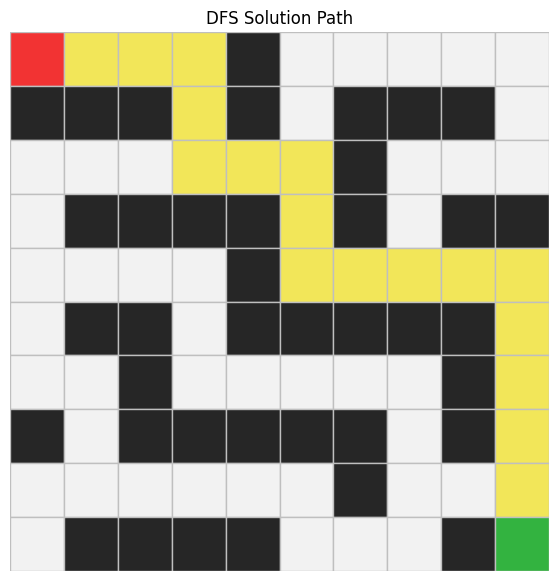

In [ ]:
# Visualise solution paths.
# After your algorithms work, choose at least two algorithms and plot their paths.

bfs_result = results[0]
dfs_result = results[1]
ids_result = results[3]

plot_path(
    sample_grid,
    start,
    goal,
    path=bfs_result.path,
    title="BFS Solution Path",
)

plot_path(
    sample_grid,
    start,
    goal,
    path=dfs_result.path,
    title="DFS Solution Path",
)


In [ ]:

custom_grid_1 = [
    # Replace this with your own grid.
    [0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0],
    [1, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0],
    [0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0],
    [0, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 0],
    [0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0],
    [1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 0, 1, 1, 0],
    [0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0],
    [0, 1, 1, 0, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0],
    [0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0],
    [1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0],
    [0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0],
    [0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 0],
    [0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0],
    [1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 0],
    [0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0]    
]

custom_start_1 = (0, 0)
custom_goal_1 = (14, 10)

# Example after completing:
custom_problem_1 = GridProblem(custom_grid_1, custom_start_1, custom_goal_1)
custom_results_1 = [
    bfs.search(custom_problem_1),
    dfs.search(custom_problem_1),
    dls.search(custom_problem_1, limit=20),
    ids.search(custom_problem_1, max_depth=40),
]
show_results(custom_results_1)

,Algorithm,Status,Limit,Solution depth,Solution cost,Nodes expanded,Max frontier/stack,Reached states
0,BFS,SUCCESS,NaN,24.0,24.0,83,7,0
1,DFS,SUCCESS,NaN,32.0,32.0,32,8,0
2,DLS,CUTOFF,20.0,NaN,NaN,153,21,0
3,IDS,SUCCESS,24.0,24.0,24.0,1796,25,0


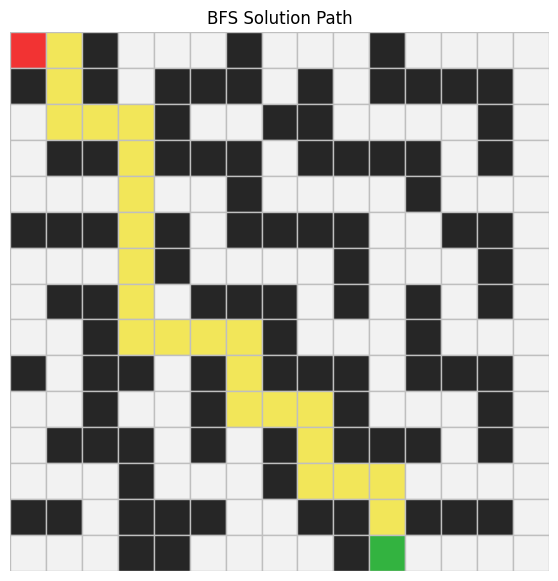

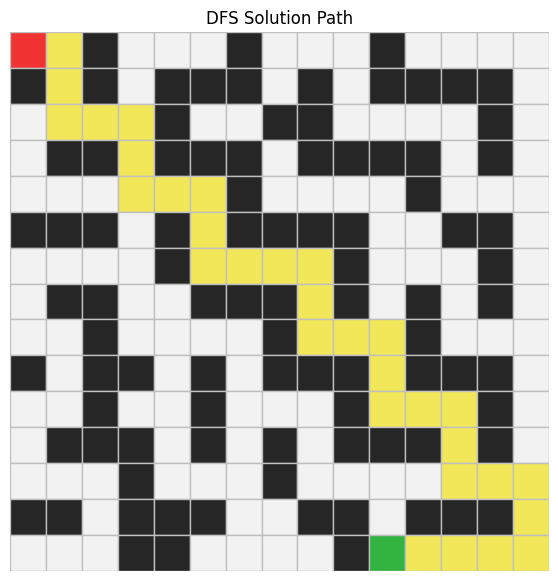

In [ ]:
# Visualise solution paths.
# After your algorithms work, choose at least one algorithms and plot their paths.

bfs_result = custom_results_1[0]
dfs_result = custom_results_1[1]
ids_result = custom_results_1[3]

plot_path(
    custom_grid_1,
    custom_start_1,
    custom_goal_1,
    path=bfs_result.path,
    title="BFS Solution Path",
)

plot_path(
    custom_grid_1,
    custom_start_1,
    custom_goal_1,
    path=dfs_result.path,
    title="DFS Solution Path",
)



The first custom map is a 15×15 maze containing multiple branches and dead ends. 
BFS found the shortest path with a solution depth of 24 and expanded 83 nodes, confirming that it guarantees optimal solutions by exploring level by level. DFS also reached the goal but produced a longer path of depth 32, showing that it does not guarantee an optimal solution, even though it expanded 32 nodes

In [ ]:
custom_grid2 = [
    # Replace this with your own grid.
    [0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0],
    [1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0],
    [0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0],
    [0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 0],
    [0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0],
    [0, 1, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0],
    [0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
    [0, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0],
    [0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0],
    [0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0],
    [0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0],
    [0, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0],
    [0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0],
    [0, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0],
    [0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0],
    [0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0],
    [0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0],
    [0, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0],
    [0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0]
]

custom_start_2 = (2, 0)
custom_goal_2 = (19, 7)

# Example after completing:
custom_problem_2 = GridProblem(custom_grid2, custom_start_2, custom_goal_2)
custom_results_2 = [
    bfs.search(custom_problem_2),
    dfs.search(custom_problem_2),
    dls.search(custom_problem_2, limit=20),
    ids.search(custom_problem_2, max_depth=40),
]
show_results(custom_results_2)

,Algorithm,Status,Limit,Solution depth,Solution cost,Nodes expanded,Max frontier/stack,Reached states
0,BFS,SUCCESS,NaN,24.0,24.0,88,7,0
1,DFS,SUCCESS,NaN,84.0,84.0,94,15,0
2,DLS,CUTOFF,20.0,NaN,NaN,191,21,0
3,IDS,SUCCESS,24.0,24.0,24.0,1968,25,0


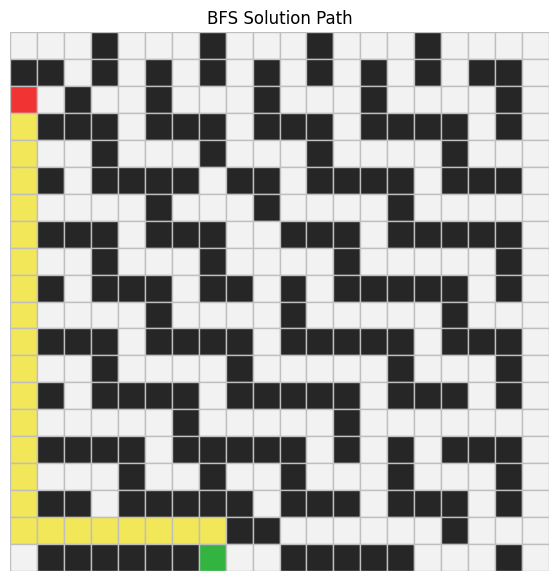

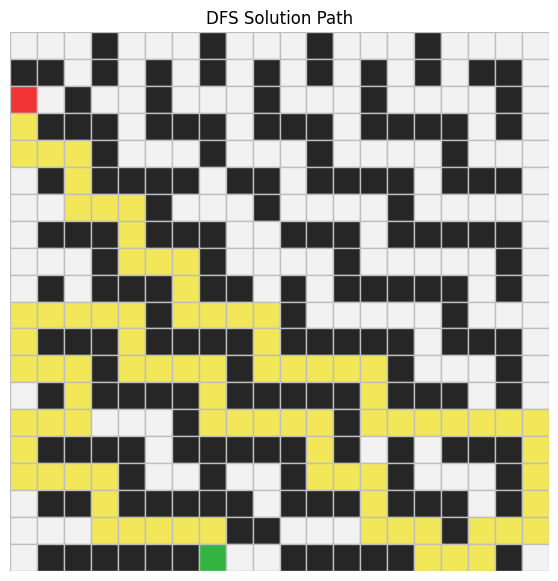

In [ ]:
bfs_result = custom_results_2[0]
dfs_result = custom_results_2[1]


plot_path(
    custom_grid2,
    custom_start_2,
    custom_goal_2,
    path=bfs_result.path,
    title="BFS Solution Path",
)
plot_path(
    custom_grid2,
    custom_start_2,
    custom_goal_2,
    path=dfs_result.path,
    title="DFS Solution Path",
)

BFS found the shortest path with a solution depth of 24 and expanded 88 nodes, confirming that it guarantees optimal solutions by exploring level by level. DFS also reached the goal but produced a longer path of depth 84, showing that it does not guarantee an optimal solution, even though it expanded 94 nodes

Q1. A state represents or describes the current situation or environment of an agent.

Q2.An action is something an agent can do in or from a state.

Q3.The result function determines the new or curnt state an agent is in after an action has been taken.

Q4.It is important to separate the problem definition from the search algorithm because the search algorithm does not need to know the specific details of the problem. The problem definition provides the initial state, goal test, actions, result function, and action costs. We separate them because the search algorithm only asks questions like: What is the cost? Have I reached the goal state? and What states can I explore next?


BFS (Breadth-First Search) uses a FIFO (First-In, First-Out) queue because it explores states in the order they are discovered. This ensures that the first state added to the frontier is the first one to be explored. As a result, BFS explores all nodes at the current depth level before moving to the next level. This helps avoid missing shorter paths and ensures systematic exploration, reducing the chance of revisiting nodes unnecessarily when a visited/reached set is used.

Q2.In an unweighted grid every move has the samee cost and since BFS explores the states by increasing depth. the BFS reaches the goal it hav reached it using feewest possible moves. so it wil return thr shortest path in terms of thr numbr of moves.

Q3. The reached set keeps track of the states that an agent has already explored. It helps ensure that the agent does not revisit those states again, preventing repeated work and avoiding infinite cycles in the search process.

DFS (Depth-First Search) uses a stack because it follows a LIFO (Last-In, First-Out) order. This allows DFS to explore one path as deeply as possible before backtracking. The most recently discovered node is explored first, leading the search to go deep along a branch before exploring other branches.

Q2.DFS returns the first goal it finds, not necessarily the closest one, even if there is a shorter path. Therefore, DFS is not guaranteed to find the shortest path.

Q3.DFS can use less memory than BFS when the tree is very deep, the branching factor is large, memory is limited, and only a solution (not the shortest path) is needed.

Q4.DFS performs poorly when the search tree is very deep. If the graph contains cycles, the search space can become infinite.




Q1.When the depth limit is smalle than the depth goal , the DLS cannot reach the goal it cutoff on its path.

Q2.Cutoff means a search has been stopped because the depth limit was reached, while there was still a solution deeper in the tree. 

Q3. The DFS has no depth limit, can go infinitely deep, may never return in infinite trees and can explore all depths, while the DLS has a maximum depth limit, stops at the limit, is guaranteed to stop and explores only up to the limit.

Q4. Path-cycle checking helps prevent the agent from visiting already visited states or states already on the current path.

Q1.Since IDS doesn’t know how deep the goal is, it runs DLS repeatedly until it finds the goal. This guarantees that if a solution exists, it will be found

Q2.A single DLS may fail because its depth limit is too small, hence the goal cannot be reached. However, IDS keeps increasing the limit until it becomes large enough to reach the goal.

Q3.BFS stores all frontier nodes at a level, while IDS only stores roughly the current path, making it use less memory compared to BFS.

Q4. The cost of searching from the root is that it revisits nodes many times, making the root and upper-level nodes be expanded repeatedly.

For a route to be safer or more practical the route must have:
*Fewer obstacles (buildings, trees, power lines)
*Better weather conditions
*Lower wind speeds
*Less air traffic
*Lower battery consumption
*No-fly zones or restricted areas
*Better GPS signal coverage
*Shorter travel time

Q2. Where all costs are equal and we only care about the fewest number of moves, I'd would choose Breadth-First Search because every move has the same cost, and BFS explores states level by level. The first time it reaches the goal, it has found the path with the fewest moves.

Q3.When there is a limit on how deep the drone is allowed to search, I'd use Depth-Limited Search because:
*DLS allows you to set a maximum search depth.
*The drone will not explore beyond that limit.
*This prevents excessive searching and reduces resource usage.

Q4.The grid model is a simplification and ignores many real-world factors:
*Drones move in 3D, not just up, down, left, and right.
*Weather conditions (wind, rain, fog) are ignored.
*Obstacles may move (birds, aircraft, vehicles).
*Battery usage is not modeled.
*Different altitudes are not considered.
*GPS errors and sensor inaccuracies are ignored.
*Airspace regulations and no-fly zones may be more complex.
*Real routes often have different travel costs, speeds, and risks